# RQ2: Feature Group Effectiveness

**Research question:** How does the use of different feature groups, including content-related, platform-related, temporal, and creator-related features, affect prediction performance?

## 1. Setup

In [1]:
# Import model families used to compare feature-group predictive value.
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
TARGET = "trend_label"

pd.set_option("display.max_columns", 100)


## 2. Load Processed Data

In [2]:
# Load processed splits and the encoded-feature to group mapping.
train = pd.read_csv("../data/processed/train.csv")
validation = pd.read_csv("../data/processed/validation.csv")
test = pd.read_csv("../data/processed/test.csv")
feature_group_table = pd.read_csv("../data/processed/feature_groups.csv")

X_train = train.drop(columns=TARGET)
y_train = train[TARGET]

X_val = validation.drop(columns=TARGET)
y_val = validation[TARGET]

X_test = test.drop(columns=TARGET)
y_test = test[TARGET]

# Output: split shapes and training class distribution.
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

display(y_train.value_counts(normalize=True).sort_index())

Train: (33655, 203) (33655,)
Validation: (7212, 203) (7212,)
Test: (7212, 203) (7212,)


trend_label
declining    0.249651
rising       0.251701
seasonal     0.252622
stable       0.246026
Name: proportion, dtype: float64

## 3. Feature Groups

In [3]:
# Build feature-group column lists from preprocessing metadata.
feature_groups = {
    group: group_df["feature"].tolist()
    for group, group_df in feature_group_table.groupby("feature_group")
}

feature_groups = {
    group: [column for column in columns if column in X_train.columns]
    for group, columns in feature_groups.items()
}
# Include the full feature set as the benchmark against single groups.
feature_groups["all_features"] = X_train.columns.tolist()

feature_group_summary = pd.DataFrame([
    {"feature_group": group, "n_columns": len(columns)}
    for group, columns in feature_groups.items()
]).sort_values("feature_group")

# Output: number of encoded columns available in each feature group.
display(feature_group_summary)

,feature_group,n_columns
5,all_features,203
0,content_basic,17
1,creator,3
2,engagement_observed,20
3,metadata,138
4,temporal,25


## 4. Group Experiments with Three Models

Each feature group is evaluated with three non-neural models: `LogisticRegression`, `KNeighborsClassifier`, and `RandomForestClassifier`. Macro F1 is the main comparison metric because the task is multi-class and each class should count equally.

In [4]:
# Train each model on each feature group and score on validation data.
models = {
    "logistic_regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
    ),
    "knn": make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=15, weights="distance", n_jobs=-1),
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=100,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
}

# Baseline ignores features, so it is evaluated once.
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_val)

rows = [{
    "model": "majority_baseline",
    "feature_group": "none",
    "n_columns": 0,
    "accuracy": accuracy_score(y_val, baseline_pred),
    "macro_f1": f1_score(y_val, baseline_pred, average="macro"),
}]
trained_models = {}

# Clone models so every feature-group experiment starts from an unfitted estimator.
for model_name, model in models.items():
    for group_name, columns in feature_groups.items():
        fitted_model = clone(model)
        fitted_model.fit(X_train[columns], y_train)
        y_pred = fitted_model.predict(X_val[columns])

        # Store validation accuracy and macro F1 for this model/group pair.
        rows.append({
            "model": model_name,
            "feature_group": group_name,
            "n_columns": len(columns),
            "accuracy": accuracy_score(y_val, y_pred),
            "macro_f1": f1_score(y_val, y_pred, average="macro"),
        })
        trained_models[(model_name, group_name)] = fitted_model

results = pd.DataFrame(rows).sort_values("macro_f1", ascending=False).reset_index(drop=True)
# Output: validation metrics table ranked by macro F1.
display(results.round(4))

,model,feature_group,n_columns,accuracy,macro_f1
0,random_forest,all_features,203,0.2601,0.2600
1,knn,metadata,138,0.2546,0.2546
2,random_forest,metadata,138,0.2547,0.2545
3,knn,temporal,25,0.2539,0.2517
4,knn,content_basic,17,0.2522,0.2512
5,knn,all_features,203,0.2512,0.2511
6,random_forest,content_basic,17,0.2506,0.2505
7,random_forest,engagement_observed,20,0.2503,0.2502
8,knn,creator,3,0.2517,0.2496
9,random_forest,temporal,25,0.2496,0.2496


model,knn,logistic_regression,random_forest
feature_group,,,
creator,0.2496,0.1686,0.2469
engagement_observed,0.2495,0.2481,0.2502
content_basic,0.2512,0.2427,0.2505
temporal,0.2517,0.2319,0.2496
metadata,0.2546,0.2416,0.2545
all_features,0.2511,0.2399,0.2600


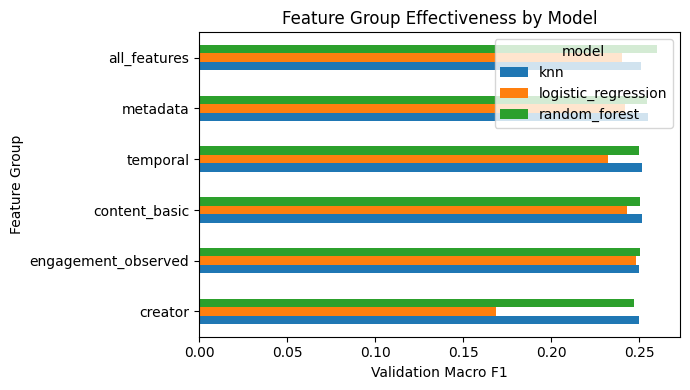

In [5]:
# Reshape validation macro F1 scores for easier comparison across groups.
validation_pivot = (
    results[results["model"] != "majority_baseline"]
    .pivot(index="feature_group", columns="model", values="macro_f1")
)
validation_pivot = validation_pivot.loc[validation_pivot.max(axis=1).sort_values().index]

# Output: macro F1 matrix with feature groups as rows and models as columns.
display(validation_pivot.round(4))

# Diagram: horizontal comparison of validation macro F1 by feature group.
validation_pivot.plot(kind="barh", figsize=(7, 4))
plt.xlabel("Validation Macro F1")
plt.ylabel("Feature Group")
plt.title("Feature Group Effectiveness by Model")
plt.tight_layout()
plt.show()

## 5. Best Validation Combination on Test Set

In [6]:
# Evaluate the best validation model/group combination on the held-out test set.
best_row = results[results["model"] != "majority_baseline"].iloc[0]
best_model_name = best_row["model"]
best_group = best_row["feature_group"]
best_columns = feature_groups[best_group]
best_model = trained_models[(best_model_name, best_group)]

# Use only the columns belonging to the selected feature group.
y_test_pred = best_model.predict(X_test[best_columns])

test_scores = pd.DataFrame([{
    "model": best_model_name,
    "feature_group": best_group,
    "n_columns": len(best_columns),
    "accuracy": accuracy_score(y_test, y_test_pred),
    "macro_f1": f1_score(y_test, y_test_pred, average="macro"),
}])

# Output: held-out test accuracy, macro F1, and per-class report.
display(test_scores.round(4))
print(classification_report(y_test, y_test_pred, digits=3))

,model,feature_group,n_columns,accuracy,macro_f1
0,random_forest,all_features,203,0.2478,0.2475


              precision    recall  f1-score   support

   declining      0.241     0.235     0.238      1801
      rising      0.261     0.271     0.266      1815
    seasonal      0.252     0.255     0.253      1822
      stable      0.235     0.230     0.233      1774

    accuracy                          0.248      7212
   macro avg      0.247     0.248     0.248      7212
weighted avg      0.248     0.248     0.248      7212

